Accuracy: 0.9630

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       543
           1       0.96      0.96      0.96       457

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000


Confusion Matrix:
[[523  20]
 [ 17 440]]


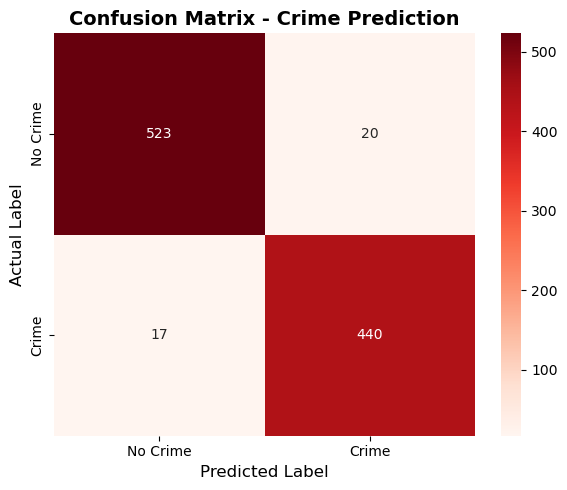

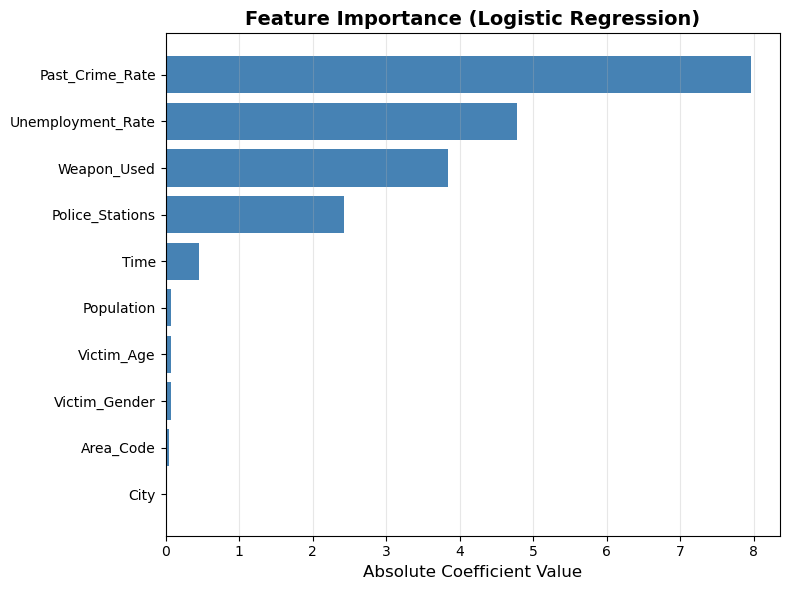


📊 Top 3 Most Important Features:
  Past_Crime_Rate: 7.9614
  Unemployment_Rate: 4.7858
  Weapon_Used: 3.8476

✅ Model saved successfully!
📁 Graphs saved: 'confusion_matrix.png' and 'feature_importance.png'


NameError: name 'crime_model' is not defined

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('crime dataset.csv')

# Encode categorical columns
le_dict = {}
cat_cols = ['City', 'Time', 'Victim_Gender', 'Weapon_Used']

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

# Features and target
features = ['City', 'Area_Code', 'Population', 'Unemployment_Rate', 
            'Police_Stations', 'Time', 'Victim_Age', 'Victim_Gender', 
            'Weapon_Used', 'Past_Crime_Rate']

X = df[features]
y = df['Crime_Occurred']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ========== GRAPH 1: Confusion Matrix Heatmap ==========
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['No Crime', 'Crime'], 
            yticklabels=['No Crime', 'Crime'])
plt.title('Confusion Matrix - Crime Prediction', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

# ========== GRAPH 2: Feature Importance ==========
plt.figure(figsize=(8, 6))
coef_abs = np.abs(model.coef_[0])
sorted_idx = np.argsort(coef_abs)
pos = np.arange(sorted_idx.shape[0]) + .5

plt.barh(pos, coef_abs[sorted_idx], color='steelblue')
plt.yticks(pos, np.array(features)[sorted_idx])
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.title('Feature Importance (Logistic Regression)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

# Print top features
print("\n📊 Top 3 Most Important Features:")
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=False)
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

# Save everything
joblib.dump(model, 'crime_model.pkl')
joblib.dump(scaler, 'crime_scaler.pkl')
joblib.dump(le_dict, 'crime_label_encoders.pkl')

print("\n✅ Model saved successfully!")
print("📁 Graphs saved: 'confusion_matrix.png' and 'feature_importance.png'")

